<a href="https://colab.research.google.com/github/sujithkumarmp/cloud-ai-basics/blob/main/hf_difusion_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from diffusers import DDPMPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [29]:
from diffusers import DDPMPipeline, UNet2DModel, DDPMScheduler
import torch

unet = UNet2DModel.from_pretrained("google/ddpm-celebahq-256").to("cpu")
scheduler = DDPMScheduler.from_pretrained("google/ddpm-celebahq-256")
ddpm = DDPMPipeline(unet=unet, scheduler=scheduler)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [3]:
image = ddpm(num_inference_steps=30).images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

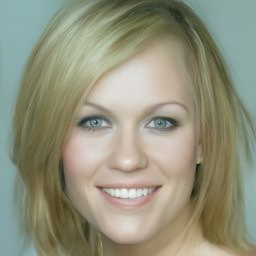

In [4]:
image

In [5]:
from diffusers import DDPMScheduler, UNet2DModel

In [7]:
scheduler = DDPMScheduler.from_pretrained("google/ddpm-celebahq-256")
model = UNet2DModel.from_pretrained("google/ddpm-celebahq-256").to('cuda')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [8]:
scheduler.set_timesteps(50)

In [9]:
import torch

In [10]:
sample_size = model.config.sample_size

In [11]:
sample_size

256

In [12]:
image.size

(256, 256)

In [13]:
noise = torch.randn((1,3,sample_size,sample_size),device='cuda')

In [14]:
input = noise
for t in scheduler.timesteps:
  with torch.no_grad():
    noise_residual = model(input,t).sample

  previous_noisy_sample = scheduler.step(noise_residual,t,input).prev_sample
  input = previous_noisy_sample

#

In [15]:
input.shape

torch.Size([1, 3, 256, 256])

In [16]:
from PIL import Image
import numpy as np


In [18]:
image = (input /2 + 0.5).clamp(0,1).squeeze()
image = (image.permute(1,2,0)*255).round().to(torch.uint8).cpu().numpy()

In [19]:
image = Image.fromarray(image)

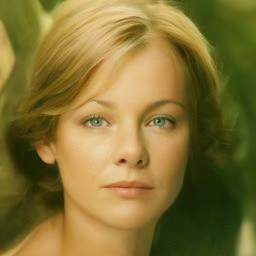

In [20]:
image

Autopipeline

In [23]:
from diffusers import AutoPipelineForText2Image

In [30]:
pipeline = AutoPipelineForText2Image.from_pretrained("dreamlike-art/dreamlike-photoreal-2.0", torch_dtype=torch.bfloat16, device_map="cuda")

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--dreamlike-art--dreamlike-photoreal-2.0/snapshots/d9e27ac81cfa72def39d74ca673219c349f0a0d5/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
prompt = "Cinematic photo of Elmo from Sesame street in Paris, 35 mm photo, film"
pipeline.enable_model_cpu_offload()
image= pipeline(prompt, height=256, width=256).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

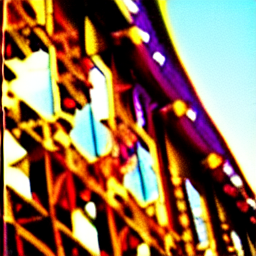

In [41]:
image